# Análisis descriptivo de variables cualitativas

Se va a trabajar con el dataset conocido como "adult dataset", cuya información está disponible en el siguiente enlace: https://archive.ics.uci.edu/dataset/2/adult.

Se va a cargar directamente desde la web.

In [1]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
           'income'],
    na_values=' ?'
    )

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Con el método `info()` identificamos que variables Pandas tipeo como objeto, esto es, como cadenas de texto. Estas variables las trataremos como variables categóricas.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Como se va a trabajar únicamente con las variables categóricas, se van a filtrar:

In [3]:
df = df.select_dtypes('object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   workclass       30725 non-null  object
 1   education       32561 non-null  object
 2   marital-status  32561 non-null  object
 3   occupation      30718 non-null  object
 4   relationship    32561 non-null  object
 5   race            32561 non-null  object
 6   sex             32561 non-null  object
 7   native-country  31978 non-null  object
 8   income          32561 non-null  object
dtypes: object(9)
memory usage: 2.2+ MB


## Tablas de frecuencias

Las tablas de frecuencia son la base de la estadística descriptiva de variables categóricas. En Pandas, estas se pueden crear con el método `value_counts()`.

Por defecto, este método entrega la frecuencia absoluta:

In [4]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


Pero con el argumento `normalize=True` se puede obtener las frecuencias relativas y porcentuales.



In [5]:
df['workclass'].value_counts(normalize=True)

,proportion
workclass,
Private,0.738682
Self-emp-not-inc,0.082701
Local-gov,0.068120
State-gov,0.042246
Self-emp-inc,0.036322
Federal-gov,0.031245
Without-pay,0.000456
Never-worked,0.000228


Para obtener la frecucnia porcentual habría que multiplicar por 100:

In [6]:
100*df['workclass'].value_counts(normalize=True).round(4)

,proportion
workclass,
Private,73.87
Self-emp-not-inc,8.27
Local-gov,6.81
State-gov,4.22
Self-emp-inc,3.63
Federal-gov,3.12
Without-pay,0.05
Never-worked,0.02


Por defecto, esta función presenta las categorías ordenadas de mayor frecuencia a menor frecuencia, pero se puede cambiar este comportamiento:

In [7]:
df['workclass'].value_counts(normalize=True, sort=False)

,proportion
workclass,
State-gov,0.042246
Self-emp-not-inc,0.082701
Private,0.738682
Federal-gov,0.031245
Local-gov,0.068120
Self-emp-inc,0.036322
Without-pay,0.000456
Never-worked,0.000228


In [8]:
df['workclass'].value_counts(ascending=True)

,count
workclass,
Never-worked,7
Without-pay,14
Federal-gov,960
Self-emp-inc,1116
State-gov,1298
Local-gov,2093
Self-emp-not-inc,2541
Private,22696


## Cambio a tipo "category"

Aunque la gran mayoría de métodos para variables categóricas funcionan bien con las variables tipo "object", es buena práctica cambiarles al tipo "category", sobretodo si son nominales:

In [9]:
df1 = df.copy()

In [10]:
df1['workclass'] = df1['workclass'].astype('category')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   workclass       30725 non-null  category
 1   education       32561 non-null  object  
 2   marital-status  32561 non-null  object  
 3   occupation      30718 non-null  object  
 4   relationship    32561 non-null  object  
 5   race            32561 non-null  object  
 6   sex             32561 non-null  object  
 7   native-country  31978 non-null  object  
 8   income          32561 non-null  object  
dtypes: category(1), object(8)
memory usage: 2.0+ MB


Las variables "category" tienen varios atributos, entre ellos las categorías de la variable, y los códigos que asigna a cada categoría:

In [11]:
df1.workclass.cat.categories

Index([' Federal-gov', ' Local-gov', ' Never-worked', ' Private',
       ' Self-emp-inc', ' Self-emp-not-inc', ' State-gov', ' Without-pay'],
      dtype='object')

In [12]:
df1.workclass.cat.codes

,0
0,6
1,5
2,3
3,3
4,3
...,...
32556,3
32557,3
32558,3
32559,3


Obsérvese cómo cambia el comportamiento de este método con una variable "category":

In [13]:
df1['workclass'].value_counts(sort=False)

,count
workclass,
Federal-gov,960
Local-gov,2093
Never-worked,7
Private,22696
Self-emp-inc,1116
Self-emp-not-inc,2541
State-gov,1298
Without-pay,14


Por defecto, Pandas toma como categorías las que encuentra en la variable (que se pueden obtener mediante el método `unique()`), y para asignarle un código a cada categoría las ordena alfabéticamente.

Para una variable ordinal es necesario especificar las categorías y el orden de estas. En este caso, ya es necesario usar el método `pd.Categorical()`.

In [14]:
df1['education'].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [15]:
# Convertir en variable "category" education:

df1['education'] = pd.Categorical(
    df1['education'],
    categories=[' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th',
                ' 11th', ' 12th', ' HS-grad', ' Some-college', ' Bachelors',
                ' Masters', ' Doctorate'],
    ordered=True
    )

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   workclass       30725 non-null  category
 1   education       29536 non-null  category
 2   marital-status  32561 non-null  object  
 3   occupation      30718 non-null  object  
 4   relationship    32561 non-null  object  
 5   race            32561 non-null  object  
 6   sex             32561 non-null  object  
 7   native-country  31978 non-null  object  
 8   income          32561 non-null  object  
dtypes: category(2), object(7)
memory usage: 1.8+ MB


In [16]:
df1['education'].cat.categories

Index([' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th',
       ' 11th', ' 12th', ' HS-grad', ' Some-college', ' Bachelors', ' Masters',
       ' Doctorate'],
      dtype='object')

In [17]:
df1['education'].cat.codes

,0
0,10
1,10
2,8
3,6
4,10
...,...
32556,-1
32557,8
32558,8
32559,8


Nótese como Pandas muestra que las categorías están ordenadas:

In [18]:
df1['education'].unique()

[' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th', ..., ' 5th-6th', ' 10th', ' 1st-4th', ' Preschool', ' 12th']
Length: 14
Categories (13, object): [' Preschool' < ' 1st-4th' < ' 5th-6th' < ' 7th-8th' ... ' Some-college' <
                          ' Bachelors' < ' Masters' < ' Doctorate']

También nótese como las categorías que no fueron incluídas en el listado (en este caso "Assoc-acdm", "Assoc-voc" y "Prof-school"), desaparecen de las tablas de frecuencias:

In [19]:
df1['education'].value_counts(sort=False)

,count
education,
Preschool,51
1st-4th,168
5th-6th,333
7th-8th,646
9th,514
10th,933
11th,1175
12th,433
HS-grad,10501


Compárese lo que muestra la tabla de la variable "education" sin cambiarle el tipo:

Las categorías no incluidas se convierten en **datos nulos**:

In [20]:
df1['education'].isnull().sum()

np.int64(3025)

In [21]:
df['education'].isnull().sum()

np.int64(0)

Vamos a adicionar estas categorías para no afectar la variable:

In [22]:
df1 = df.copy()
df1['education'] = pd.Categorical(
    df1['education'],
    categories=[' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th',
                ' 11th', ' 12th', ' HS-grad', ' Some-college', ' Assoc-voc',
                ' Assoc-acdm', ' Prof-school',' Bachelors', ' Masters', ' Doctorate'],
    ordered=True
    )

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   workclass       30725 non-null  object  
 1   education       32561 non-null  category
 2   marital-status  32561 non-null  object  
 3   occupation      30718 non-null  object  
 4   relationship    32561 non-null  object  
 5   race            32561 non-null  object  
 6   sex             32561 non-null  object  
 7   native-country  31978 non-null  object  
 8   income          32561 non-null  object  
dtypes: category(1), object(8)
memory usage: 2.0+ MB


Recordemos que la frecuencia acumulada solo tiene sentido para las variables ordinales. Esta se puede calcular así:

In [23]:
100*df1['education'].value_counts(normalize=True, sort=False).cumsum()

,proportion
education,
Preschool,0.156629
1st-4th,0.672584
5th-6th,1.695280
7th-8th,3.679248
9th,5.257824
10th,8.123215
11th,11.731826
12th,13.061638
HS-grad,45.311876


## Estadísticas descriptivas

Para variables nominales la única estadística válida es la moda:

In [24]:
df1['workclass'].mode()

,workclass
0,Private


Para variables ordinales, además de la moda, son válidas la mediana y los cuantiles:

In [25]:
df1['education'].mode()

,education
0,HS-grad


Para calcular la mediana y los cuantiles deben usarse los atributos:

In [26]:
df1['education'].cat.categories[df1['education'].cat.codes.median().astype(int)]

' Some-college'

In [27]:
df1['education'].cat.categories[df1['education'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index([' HS-grad', ' Some-college', ' Assoc-acdm'], dtype='object')

Por último, el método `describe()` da las estadísticas más importantes:

In [28]:
df1.describe(include=['object','category'])

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


## Gráficos

Los gráficos recomendados para variables categóricas son los de barras horizontales o verticales. Estos se pueden hacer con los métodos `plot(kind='bar')` y `plot(kind='barh')`.

<Axes: xlabel='workclass'>

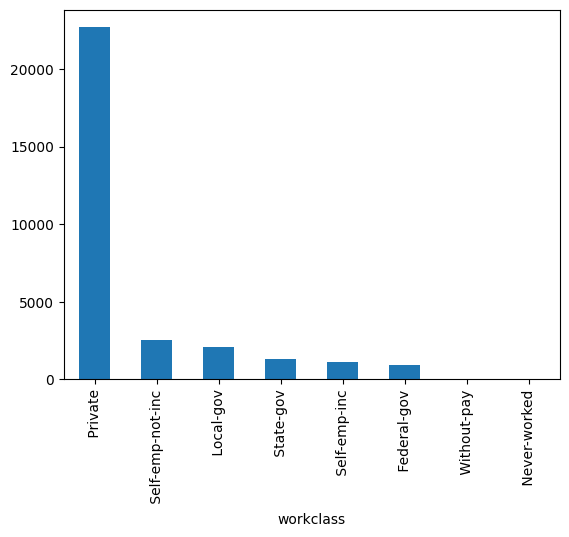

In [29]:
df1['workclass'].value_counts().plot(kind='bar')

<Axes: ylabel='workclass'>

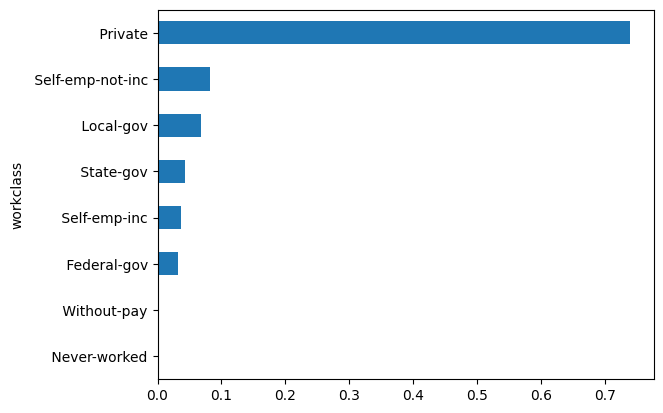

In [30]:
df1['workclass'].value_counts(normalize=True, ascending=True).plot(kind='barh')

Para las variables ordinales, también es posible graficar la frecuencia acumulada:

<Axes: ylabel='education'>

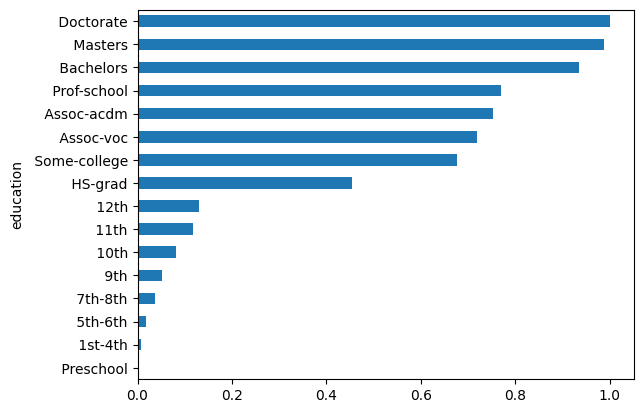

In [31]:
df1['education'].value_counts(normalize=True, sort=False).cumsum().plot(kind='barh')

Los gráficos de pastel solo se recomiendan para variables de baja cardinalidad ($<5$ categorías)

<Axes: ylabel='count'>

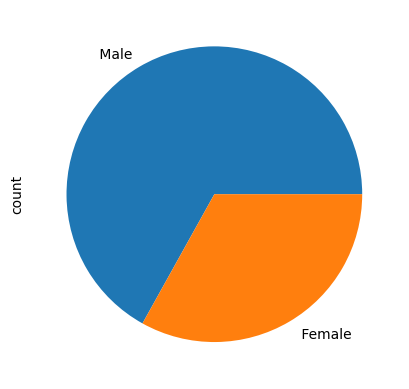

In [32]:
df1['sex'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

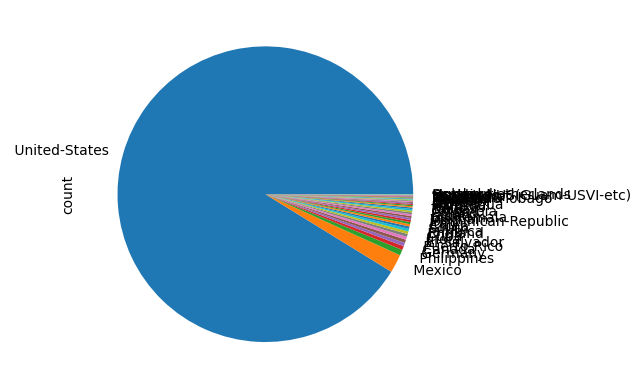

In [33]:
df1['native-country'].value_counts().plot(kind='pie')

## Variables de alta cardinalidad y categorías atípicas

Variables con más de 30 categorías atípicas pueden considerarse de alta cardinalidad. Con estas loa análisis suelen hacerse más complejos.

Veamos el caso de "native-country":

In [34]:
df1['native-country'] = df1['native-country'].astype('category')
df1['native-country'].value_counts(normalize=True)

,proportion
native-country,
United-States,0.912190
Mexico,0.020108
Philippines,0.006192
Germany,0.004284
Canada,0.003784
Puerto-Rico,0.003565
El-Salvador,0.003315
India,0.003127
Cuba,0.002971


<Axes: ylabel='native-country'>

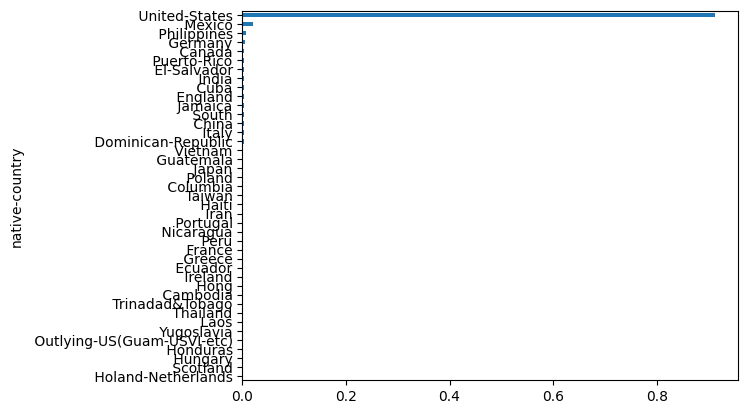

In [37]:
df1['native-country'].value_counts(normalize=True, ascending=True).plot(kind='barh')

Generalmente, las variables de alta cardinalidad suelen tener categorías atípicas. Aunque no hay un criterio absoluto, una categoría con menos de 10 muestras se pueden considerar atípicas.

In [39]:
df1['native-country'].value_counts().tail(10)

,count
native-country,
Cambodia,19
Trinadad&Tobago,19
Thailand,18
Laos,18
Yugoslavia,16
Outlying-US(Guam-USVI-etc),14
Honduras,13
Hungary,13
Scotland,12


En este caso, **Holand-Netherlands** es una categoría atípica.

Otro criterio sería considerar atípica cualquier categoria con menos del 1% de frecuencia relativa.

In [42]:
rel_freq = 100*df1['native-country'].value_counts(normalize=True)
rel_freq[rel_freq < 1]

,proportion
native-country,
Philippines,0.619176
Germany,0.428420
Canada,0.378385
Puerto-Rico,0.356495
El-Salvador,0.331478
India,0.312715
Cuba,0.297079
England,0.281443
Jamaica,0.253299


Bajo este criterio, todas las categorías serían atípicas, menos **United-States** y **Mexico**.

# Tarea

Haga un análisis descriptivo a las variables cualitativas del dataset "Telco-customer-churn.csv":

- Identifique cuáles variables son nominales y cuáles ordinales.
- Cambie el tipo de las variables de "object" a "category".
- Haga las tablas de frecuencia absoluta y relativa.
- Calcule las estadísticas descriptivas de las variables.
- Haga los gráficos de barras de frecuencias relativas de las variables.
- Identifique variables de alta cardinalidad y categorías atípicas.